# Modélisation avancée

## Informations générales

| Élément | Détail |
|---|---|
| **Propriétaire** | Tiéba Bamba |
| **Projet** | Talk to my data |
| **Domaine** | Banque de détail - Recouvrement & Risque |
| **Étape** | 3/3 - Modélisation avancée |
| **Notebook** | Optimisation des modèles candidats et sélection du modèle final |
| **Date de création** | 2 septembre 2026 |
| **Statut** | Terminé |

## Contexte métier

La direction **« Recouvrement & Risque »** d'une banque de détail souhaite renforcer sa politique de relance et de recouvrement au prochain trimestre. Le notebook d'EDA a permis de comprendre le dataset et le notebook de modélisation baseline a établi une référence chiffrée (`LogisticRegression`) puis présélectionné, par validation croisée sur le train uniquement, 4 familles de modèles candidates : **Gradient Boosting, Random Forest, LightGBM et Logistic Regression**.

Ce notebook a pour objectif de livrer un **modèle de scoring prêt à être mis en production** : optimiser ces 4 finalistes, tester si les combiner apporte un gain, choisir le modèle final et le seuil de décision alignés sur un coût métier, puis produire une évaluation finale unique et fiable.

## Objectifs de ce notebook

Ce notebook constitue la troisième et dernière étape de modélisation du projet. Il a pour objectifs de :

- optimiser les hyperparamètres des 4 modèles finalistes (`RandomizedSearchCV`), toujours sur le train uniquement ;
- tester si un ensembling des modèles optimisés (vote, stacking) surpasse le meilleur modèle individuel ;
- sélectionner le modèle final selon la PR-AUC (métrique prioritaire) et `recall@topK` ;
- choisir une stratégie de seuil de décision claire (top K% à relancer, ou seuil de probabilité) alignée sur un coût métier explicite ;
- évaluer le modèle final **une seule fois** sur le jeu de test, pour obtenir une estimation non biaisée de sa performance ;
- préparer la sauvegarde du modèle et le fichier de scoring (`id`, `proba_default`, `label_pred`), implémentés ensuite dans `src/train.py`/`src/infer.py`.

## Déroulé annoncé

1. **Initialisation** : imports et chargement des données préparées (train/test).
2. **Optimisation des hyperparamètres** : recherche sur les 4 modèles finalistes, validation croisée sur le train uniquement.
3. **Ensembling des modèles optimisés** : vote et stacking sur les 4 finalistes tunés, comparaison au meilleur modèle individuel.
4. **Sélection du modèle final** : comparaison de tous les candidats (PR-AUC, `recall@topK`, métriques secondaires).
5. **Choix du seuil de décision** : stratégie top K% ou seuil de probabilité, alignée sur un coût métier.
6. **Évaluation finale** : un seul passage sur le jeu de test, avec le modèle et le seuil retenus.
7. **Synthèse** : constats, limites, et transition vers la sauvegarde du modèle (`train.py`/`infer.py`).

## Résultat attendu

À la fin de ce notebook, nous disposerons d'un modèle de scoring optimisé, d'une stratégie de seuil de décision justifiée, et d'une évaluation finale non biaisée sur le jeu de test — prêts à être industrialisés dans `src/train.py` et `src/infer.py`.

## 1. Initialisation

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from sklearn import set_config

from src.config import TARGET_COLUMN
from src.data_prep import load_and_prepare_data, build_pipeline
from src.metrics import recall_at_k

set_config(display="diagram")

In [2]:
df_train, df_test = load_and_prepare_data()

X_train, y_train = df_train.drop(columns=[TARGET_COLUMN]), df_train[TARGET_COLUMN]
X_test, y_test = df_test.drop(columns=[TARGET_COLUMN]), df_test[TARGET_COLUMN]

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")

X_train : (2372, 25) | X_test : (593, 25)


## 2. Optimisation des hyperparamètres

On optimise les 4 finalistes retenus dans le notebook 02 (Gradient Boosting, Random Forest, LightGBM, Logistic Regression) avec `RandomizedSearchCV`. Ce choix plutôt que `GridSearchCV` : le budget de calcul (`n_iter=30`) reste constant quelle que soit la taille de l'espace de recherche de chaque modèle, alors qu'une grille exhaustive devient vite très coûteuse dès que plusieurs hyperparamètres sont combinés (ex. Random Forest ou LightGBM, 4-6 hyperparamètres chacun).

Règles méthodologiques (identiques à la présélection du notebook 02) :
- **`scoring="average_precision"` (PR-AUC)**, la métrique prioritaire du cahier des charges — la recherche optimise donc directement le bon critère, pas un proxy.
- **Même `StratifiedKFold` (5 folds) que le notebook 02**, toujours sur `X_train`/`y_train` uniquement — `X_test` reste intact.
- **`n_iter=30`** par modèle : suffisant pour couvrir raisonnablement chaque espace de recherche sans exploser le temps de calcul.

⚠️ Cette cellule prend quelques minutes à s'exécuter (LightGBM en particulier, ~3 min à lui seul).

In [3]:
from scipy.stats import randint, uniform, loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from lightgbm import LGBMClassifier

SEED = 42

finalistes = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "LightGBM": LGBMClassifier(class_weight="balanced", random_state=SEED, verbose=-1),
}

param_distributions = {
    "Logistic Regression": {
        "model__C": loguniform(1e-3, 1e2),
    },
    "Random Forest": {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", None],
    },
    "Gradient Boosting": {
        "model__n_estimators": randint(50, 300),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__max_depth": randint(2, 6),
        "model__min_samples_leaf": randint(1, 20),
        "model__subsample": uniform(0.6, 0.4),
    },
    "LightGBM": {
        "model__n_estimators": randint(50, 300),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__num_leaves": randint(15, 63),
        "model__min_child_samples": randint(5, 50),
        "model__reg_alpha": loguniform(1e-3, 10),
        "model__reg_lambda": loguniform(1e-3, 10),
    },
}

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_estimators = {}
tuning_results = []

for name, model in finalistes.items():
    pipeline = build_pipeline(model)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_distributions[name],
        n_iter=30,
        scoring="average_precision",
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)

    best_estimators[name] = search.best_estimator_
    tuning_results.append({
        "Modèle": name,
        "PR-AUC (CV)": search.best_score_,
        "Meilleurs hyperparamètres": search.best_params_,
    })

    print(f"{name}")
    print(f"  PR-AUC (CV) : {search.best_score_:.4f}")
    print(f"  Meilleurs hyperparamètres : {search.best_params_}")
    print()

Logistic Regression
  PR-AUC (CV) : 0.5701
  Meilleurs hyperparamètres : {'model__C': np.float64(0.009962513222055111)}



Random Forest
  PR-AUC (CV) : 0.6055
  Meilleurs hyperparamètres : {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 7, 'model__min_samples_split': 10, 'model__n_estimators': 427}



Gradient Boosting
  PR-AUC (CV) : 0.6170
  Meilleurs hyperparamètres : {'model__learning_rate': np.float64(0.010243250407033817), 'model__max_depth': 2, 'model__min_samples_leaf': 17, 'model__n_estimators': 268, 'model__subsample': np.float64(0.8447411578889518)}



LightGBM
  PR-AUC (CV) : 0.6086
  Meilleurs hyperparamètres : {'model__learning_rate': np.float64(0.04724511577515711), 'model__min_child_samples': 48, 'model__n_estimators': 93, 'model__num_leaves': 34, 'model__reg_alpha': np.float64(3.7173717478250508), 'model__reg_lambda': np.float64(0.1436709513866423)}



##### **Résultats de l'optimisation**

| Modèle | PR-AUC (CV, non optimisé) | PR-AUC (CV, optimisé) | Gain |
|---|---|---|---|
| Gradient Boosting | 0,586 | **0,617** | +0,031 |
| LightGBM | 0,563 | 0,609 | +0,046 |
| Random Forest | 0,562 | 0,605 | +0,043 |
| Logistic Regression | 0,550 | 0,570 | +0,020 |

**Constats** :
- L'optimisation apporte un gain réel pour les 4 modèles (+0,02 à +0,05 de PR-AUC), plus marqué pour les modèles à base d'arbres (LightGBM, Random Forest) que pour la régression logistique, dont l'espace de recherche est plus restreint (un seul hyperparamètre, `C`).
- **Gradient Boosting reste le meilleur modèle après optimisation**, confirmant le classement déjà observé sans tuning en notebook 02 — ce n'est donc pas un artefact du réglage par défaut, l'avantage est structurel sur ce jeu de données.
- Ses meilleurs hyperparamètres montrent une régularisation forte : `learning_rate` très bas (~0,010), arbres peu profonds (`max_depth=2`), beaucoup d'arbres (`n_estimators=268`) — cohérent avec la petite taille du dataset (~2372 lignes), qui demande un modèle prudent plutôt que très flexible.
- LightGBM progresse le plus en valeur absolue (+0,046) mais reste derrière Gradient Boosting. Ses meilleurs hyperparamètres trouvés (`reg_alpha` élevé, `min_child_samples=48`) montrent une forte régularisation nécessaire pour compenser des réglages par défaut trop permissifs pour ce volume de données.

La section suivante teste si combiner ces 4 modèles optimisés (vote, stacking) apporte un gain par rapport au meilleur d'entre eux pris seul.

## 3. Ensembling des modèles optimisés

On teste si combiner les 4 modèles tunés (`best_estimators` de la section précédente) apporte un gain par rapport au meilleur d'entre eux pris seul, avec deux approches :
- **`VotingClassifier` (vote souple)** : moyenne simple des probabilités prédites par les 4 modèles.
- **`StackingClassifier`** : un méta-modèle (`LogisticRegression`) apprend à combiner les prédictions des 4 modèles, via validation croisée interne pour éviter le surapprentissage sur les prédictions in-sample.

Évaluation identique aux sections précédentes : `cross_val_predict` sur `X_train`/`y_train` uniquement, PR-AUC calculée sur les prédictions hors-échantillon agrégées.

In [5]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import average_precision_score, f1_score, recall_score, precision_score
from sklearn.model_selection import cross_val_predict

estimators = [(name, est) for name, est in best_estimators.items()]

ensembles = {
    "Voting (soft)": VotingClassifier(estimators=estimators, voting="soft"),
    "Stacking": StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(max_iter=1000), cv=cv),
}

ensemble_results = []
for name, clf in ensembles.items():
    y_proba_cv = cross_val_predict(clf, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    y_pred_cv = (y_proba_cv >= 0.5).astype(int)
    ensemble_results.append({
        "Modèle": name,
        "PR-AUC": average_precision_score(y_train, y_proba_cv),
        "F1": f1_score(y_train, y_pred_cv),
        "Recall": recall_score(y_train, y_pred_cv),
        "Precision": precision_score(y_train, y_pred_cv),
        "recall@20%": recall_at_k(y_train, y_proba_cv, 0.2),
    })
    print(f"{name}")
    print(f"  PR-AUC : {ensemble_results[-1]['PR-AUC']:.4f}")
    print()

Voting (soft)
  PR-AUC : 0.5967



Stacking
  PR-AUC : 0.5982



Pour comparer équitablement aux 4 modèles individuels, on recalcule leurs métriques avec exactement la même méthode (`cross_val_predict` agrégé) : la PR-AUC moyenne par fold rapportée par `RandomizedSearchCV` en section 2 (ex. 0,617 pour Gradient Boosting) n'est pas directement comparable à une PR-AUC calculée sur des prédictions agrégées — même distinction qu'entre `cross_validate` et `cross_val_predict` déjà rencontrée en notebook 02.

In [6]:
for name, est in best_estimators.items():
    y_proba_cv = cross_val_predict(est, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    y_pred_cv = (y_proba_cv >= 0.5).astype(int)
    ensemble_results.append({
        "Modèle": name,
        "PR-AUC": average_precision_score(y_train, y_proba_cv),
        "F1": f1_score(y_train, y_pred_cv),
        "Recall": recall_score(y_train, y_pred_cv),
        "Precision": precision_score(y_train, y_pred_cv),
        "recall@20%": recall_at_k(y_train, y_proba_cv, 0.2),
    })

comparison_df = pd.DataFrame(ensemble_results).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
comparison_df.round(4)

,Modèle,PR-AUC,F1,Recall,Precision,recall@20%
0,Gradient Boosting,0.6009,0.5450,0.4350,0.7294,0.5512
1,LightGBM,0.6002,0.5425,0.5906,0.5017,0.5512
2,Stacking,0.5982,0.5584,0.4567,0.7183,0.5472
3,Voting (soft),0.5967,0.5682,0.5453,0.5931,0.5492
4,Random Forest,0.5926,0.5551,0.6299,0.4961,0.5472
5,Logistic Regression,0.5589,0.5566,0.6535,0.4847,0.5354


##### **Résultats — l'ensembling ne bat pas le meilleur modèle seul**

| Modèle | PR-AUC | F1 | Recall | Precision | recall@20% |
|---|---|---|---|---|---|
| Gradient Boosting (seul) | **0,601** | 0,545 | 0,435 | 0,729 | 0,551 |
| LightGBM (seul) | 0,600 | 0,543 | 0,591 | 0,502 | 0,551 |
| Stacking | 0,598 | 0,558 | 0,457 | 0,718 | 0,547 |
| Voting (soft) | 0,597 | 0,568 | 0,545 | 0,593 | 0,549 |
| Random Forest (seul) | 0,593 | 0,555 | 0,630 | 0,496 | 0,547 |
| Logistic Regression (seul) | 0,559 | 0,557 | 0,654 | 0,485 | 0,535 |

**Constat honnête** : contrairement à l'hypothèse de départ, ni le vote ni le stacking ne dépassent Gradient Boosting pris seul sur la PR-AUC (0,601 vs 0,598 et 0,597) — l'écart est faible mais dans le mauvais sens. Les deux ensembles battent Random Forest et Logistic Regression pris isolément, mais pas les deux meilleurs modèles individuels (Gradient Boosting, LightGBM).

**Pourquoi l'ensembling ne fonctionne pas ici** : Gradient Boosting et LightGBM sont clairement les deux meilleurs modèles et sont eux-mêmes proches l'un de l'autre (deux variantes de boosting). Les moyenner avec deux modèles nettement plus faibles (Random Forest, Logistic Regression) dilue leur signal plutôt que d'apporter de la diversité utile. L'ensembling profite surtout quand les modèles combinés ont des niveaux de performance comparables et des erreurs peu corrélées — ce n'est pas le cas ici, où un modèle domine clairement les trois autres.

**Décision** : on conserve **Gradient Boosting seul** comme meilleur candidat pour la sélection du modèle final en section suivante, sans complexifier avec un ensemble qui n'apporte pas de gain mesurable.

## 4. Sélection du modèle final

**Modèle retenu : Gradient Boosting**, avec les hyperparamètres trouvés en section 2 (`learning_rate≈0,010`, `max_depth=2`, `min_samples_leaf=17`, `n_estimators=268`, `subsample≈0,845`).

Justification, sur la base de tous les résultats obtenus jusqu'ici :
- **Meilleure PR-AUC** (métrique prioritaire du cahier des charges) parmi les 4 modèles individuels tunés, et parmi tous les candidats testés (individuels + ensembles).
- **Meilleur `recall@20%`** ex æquo avec LightGBM (0,551) — pertinent puisque la stratégie de relance finale (section 5) pourrait reposer sur un ciblage top K%.
- **Avantage confirmé à deux niveaux** : sans tuning (notebook 02) et avec tuning (section 2) — ce n'est donc pas un artefact d'un réglage particulier.
- L'ensembling (section 3) n'apporte aucun gain par rapport à ce modèle pris seul.

Avant de le considérer comme définitif, on mesure sa performance de généralisation par **validation croisée imbriquée** : la PR-AUC de 0,601-0,617 rapportée jusqu'ici vient d'un seul run de validation croisée, où les mêmes folds ont servi à la fois à choisir les hyperparamètres et à estimer la performance — un optimisme potentiel déjà signalé comme limite dans les notebooks précédents. La validation croisée imbriquée corrige ce biais : une boucle externe (5 folds) fournit l'estimation de performance, une boucle interne (5 folds, à l'intérieur de chaque fold externe) refait la recherche d'hyperparamètres à chaque fois — la performance n'est donc jamais mesurée sur des données ayant servi à choisir les réglages.

⚠️ Cette cellule prend un peu plus d'une minute à s'exécuter (25 entraînements complets : 5 folds externes × recherche interne).

In [7]:
import numpy as np
from sklearn.model_selection import cross_val_score

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gb_pipeline = build_pipeline(GradientBoostingClassifier(random_state=SEED))

nested_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_distributions["Gradient Boosting"],
    n_iter=30,
    scoring="average_precision",
    cv=inner_cv,
    random_state=SEED,
    n_jobs=-1,
)

# n_jobs=1 sur la boucle externe : la recherche interne utilise deja n_jobs=-1,
# eviter la parallelisation imbriquee.
nested_scores = cross_val_score(nested_search, X_train, y_train, cv=outer_cv, scoring="average_precision", n_jobs=1)

print("PR-AUC par fold externe :", np.round(nested_scores, 4))
print(f"Moyenne : {nested_scores.mean():.4f}  |  Ecart-type : {nested_scores.std():.4f}")

PR-AUC par fold externe : [0.6949 0.5525 0.6334 0.5735 0.5822]
Moyenne : 0.6073  |  Ecart-type : 0.0512


##### **Résultats de la validation croisée imbriquée**

| Fold externe | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|
| PR-AUC | 0,695 | 0,553 | 0,633 | 0,574 | 0,582 |

**Moyenne : 0,607 — Écart-type : 0,051**

**Constats** :
- La moyenne (0,607) est cohérente avec les estimations précédentes (0,601 en `cross_val_predict` simple, 0,617 en moyenne de folds `RandomizedSearchCV`) — pas de biais optimiste majeur détecté sur ce modèle précis.
- **L'écart-type de 0,051 est important à noter** : les scores varient de 0,553 à 0,695 selon le fold externe, un écart de 0,14. Ça confirme une limite déjà signalée dans les notebooks précédents ("un seul run de CV, variance non quantifiée") — avec ~2372 lignes d'entraînement, la performance mesurée dépend non négligeablement de la répartition des données, pas seulement du modèle.
- **Implication concrète** : la vraie performance de Gradient Boosting sur des données non vues se situe plus probablement dans une fourchette (~0,55 à ~0,70) qu'à une valeur précise à 3 décimales. Les comparaisons fines entre modèles proches (ex. Gradient Boosting 0,601 vs LightGBM 0,600 en section 3) doivent être lues avec cette variance en tête — l'écart entre les deux est largement dans la marge d'incertitude.

Cette estimation par validation croisée imbriquée est plus fiable que les PR-AUC ponctuelles rapportées jusqu'ici, car elle ne réutilise jamais les mêmes données pour choisir les hyperparamètres et pour mesurer la performance. Elle sert de référence pour juger si le résultat du test final (section 6) est cohérent avec ce qu'on pouvait attendre.

## 5. Choix du seuil de décision

Le seuil est choisi **maintenant, sur le train uniquement** — avant tout contact avec le test (voir la discussion méthodologique : décider le seuil en regardant le test biaiserait la lecture finale).

Approche retenue : **minimisation d'un coût métier**, plutôt qu'un objectif de Recall arbitraire (ce qu'on avait fait dans un premier essai en notebook 02). On modélise :
- le coût d'un défaut manqué (faux négatif) : `R` fois plus élevé que celui d'une relance inutile ;
- le coût d'une relance inutile (faux positif) : coût unitaire de référence (= 1).

`R` (le ratio des deux coûts) n'est pas connu précisément sans chiffres réels de la direction Recouvrement & Risque — on teste donc plusieurs valeurs illustratives (3, 5, 10, 20) pour montrer comment le seuil optimal en dépend, plutôt que de figer un choix arbitraire sans le justifier.

In [8]:
gb_final = best_estimators["Gradient Boosting"]
y_proba_final_cv = cross_val_predict(gb_final, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
y_true = y_train.values

cost_curves = {}
best_thresholds = {}

for R in [3, 5, 10, 20]:
    costs = []
    for t in thresholds:
        y_pred_t = (y_proba_final_cv >= t).astype(int)
        fn = ((y_true == 1) & (y_pred_t == 0)).sum()
        fp = ((y_true == 0) & (y_pred_t == 1)).sum()
        costs.append(R * fn + fp)
    costs = np.array(costs)
    cost_curves[R] = costs
    best_thresholds[R] = thresholds[np.argmin(costs)]

for R, t in best_thresholds.items():
    y_pred_t = (y_proba_final_cv >= t).astype(int)
    n_relance = y_pred_t.sum()
    rec = recall_score(y_train, y_pred_t)
    prec = precision_score(y_train, y_pred_t)
    print(f"R={R:>2} : seuil={t:.3f}  clients relancés={n_relance} ({n_relance/len(y_true)*100:.1f}%)  recall={rec:.3f}  precision={prec:.3f}")

R= 3 : seuil=0.210  clients relancés=578 (24.4%)  recall=0.608  precision=0.535
R= 5 : seuil=0.180  clients relancés=703 (29.6%)  recall=0.661  precision=0.478
R=10 : seuil=0.110  clients relancés=1615 (68.1%)  recall=0.888  precision=0.279
R=20 : seuil=0.070  clients relancés=2368 (99.8%)  recall=1.000  precision=0.215


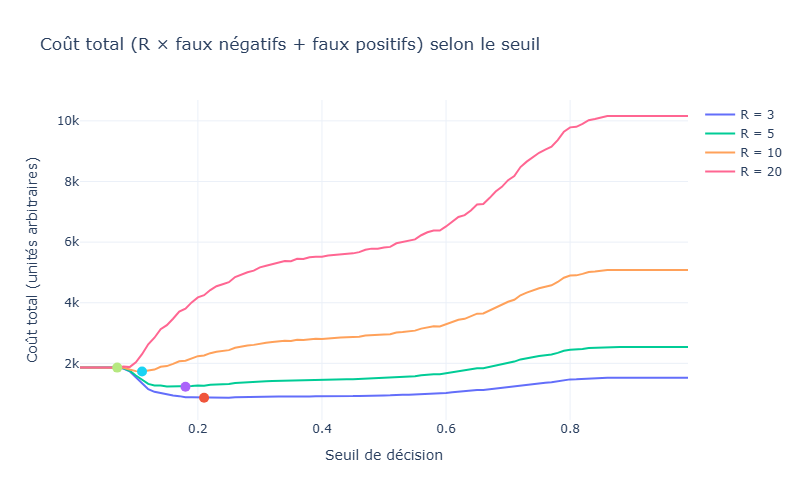

In [9]:
import plotly.graph_objects as go
from IPython.display import HTML, display

fig = go.Figure()
for R, costs in cost_curves.items():
    fig.add_trace(go.Scatter(x=thresholds, y=costs, name=f"R = {R}", mode="lines"))
    fig.add_trace(go.Scatter(
        x=[best_thresholds[R]], y=[costs.min()],
        mode="markers", marker={"size": 10}, showlegend=False,
    ))

fig.update_layout(
    title="Coût total (R × faux négatifs + faux positifs) selon le seuil",
    xaxis_title="Seuil de décision",
    yaxis_title="Coût total (unités arbitraires)",
    template="plotly_white",
    height=500,
    width=800,
)

fig.show("png")

##### **Résultats — sensibilité du seuil optimal au ratio de coût**

| R (coût défaut manqué / coût relance) | Seuil optimal | Clients relancés | Recall | Precision |
|---|---|---|---|---|
| 3 | 0,210 | 578 (24,4 %) | 0,608 | 0,535 |
| 5 | 0,180 | 703 (29,6 %) | 0,661 | 0,478 |
| 10 | 0,110 | 1615 (68,1 %) | 0,888 | 0,279 |
| 20 | 0,070 | 2368 (99,8 %) | 1,000 | 0,215 |

**Constats** :
- Le seuil optimal baisse mécaniquement quand `R` augmente : plus un défaut manqué est considéré coûteux par rapport à une relance inutile, plus il devient rationnel de relancer largement.
- **`R=20` dégénère** : la stratégie optimale devient "relancer quasiment tout le portefeuille" (99,8 %, Precision = 0,215, c'est-à-dire le taux de base — le modèle n'apporte alors plus de ciblage réel). C'est un signal que des ratios de coût extrêmes rendent le modèle de scoring inutile : au-delà d'un certain point, mieux vaut relancer tout le monde sans avoir besoin de prédire quoi que ce soit.
- Entre `R=3` et `R=5`, le comportement reste raisonnable et actionnable (24 à 30 % du portefeuille relancé, Precision entre 0,48 et 0,54).

**Seuil retenu : `R=5`**, un défaut manqué coûte environ 5 fois plus cher qu'une relance inutile. C'est un ordre de grandeur courant en recouvrement (le coût d'un appel ou d'un courrier de relance est faible comparé à l'exposition d'un compte en défaut), mais **cette valeur reste une hypothèse illustrative** — à affiner avec de vrais chiffres de coûts de relance et de taux de recouvrement une fois disponibles auprès de la direction Recouvrement & Risque.

**Seuil de décision final : 0,180** — soit une stratégie équivalente à relancer environ les **30 % de clients au score le plus élevé**, capturant 66 % des vrais défauts avec une Precision de 0,48.

In [10]:
FINAL_THRESHOLD = best_thresholds[5]
print(f"Seuil de décision final retenu : {FINAL_THRESHOLD:.3f}")

Seuil de décision final retenu : 0.180


## 6. Évaluation finale

**Premier et unique contact avec `X_test`/`y_test`** dans tout le processus de modélisation. Le modèle (Gradient Boosting, hyperparamètres de la section 2) et le seuil (0,180, section 5) sont déjà figés — rien n'est ajusté à partir de ce qui suit.

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_proba_test = gb_final.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= FINAL_THRESHOLD).astype(int)

print(f"PR-AUC     : {average_precision_score(y_test, y_proba_test):.4f}")
print(f"Accuracy   : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"F1-score   : {f1_score(y_test, y_pred_test):.4f}")
print(f"Recall     : {recall_score(y_test, y_pred_test):.4f}")
print(f"Precision  : {precision_score(y_test, y_pred_test):.4f}")
print(f"recall@30% : {recall_at_k(y_test, y_proba_test, 0.3):.4f}")
print(f"Clients relancés : {y_pred_test.sum()} / {len(y_test)} ({y_pred_test.sum()/len(y_test)*100:.1f} %)")

PR-AUC     : 0.5338
Accuracy   : 0.7268
F1-score   : 0.4774
Recall     : 0.5827
Precision  : 0.4044
recall@30% : 0.5748
Clients relancés : 183 / 593 (30.9 %)


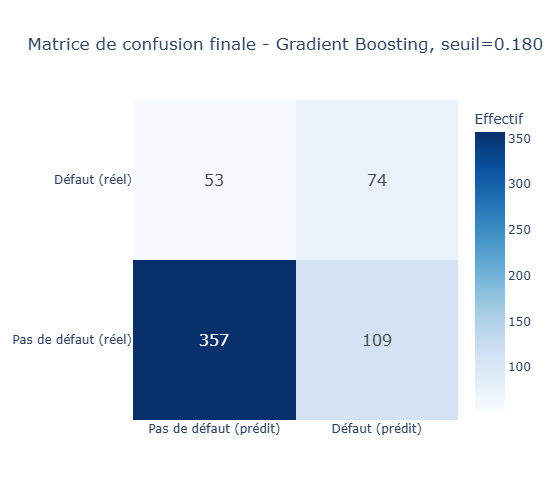

In [12]:
cm_final = confusion_matrix(y_test, y_pred_test)

fig = go.Figure(
    data=go.Heatmap(
        z=cm_final,
        x=["Pas de défaut (prédit)", "Défaut (prédit)"],
        y=["Pas de défaut (réel)", "Défaut (réel)"],
        colorscale="Blues",
        text=cm_final,
        texttemplate="%{text}",
        textfont={"size": 16},
        colorbar={"title": "Effectif"},
    )
)

fig.update_layout(
    title=f"Matrice de confusion finale - Gradient Boosting, seuil={FINAL_THRESHOLD:.3f} (jeu de test)",
    template="plotly_white",
    height=500,
    width=550,
)

fig.show("png")

##### **Résultats finaux sur le test**

| Métrique | Valeur |
|---|---|
| PR-AUC | 0,534 |
| Accuracy | 0,727 |
| F1-score | 0,477 |
| Recall | 0,583 |
| Precision | 0,404 |
| recall@30% | 0,575 |
| Clients relancés | 183 / 593 (30,9 %) |

**Matrice de confusion** : 74 vrais défauts détectés, 53 manqués, 109 fausses alertes, 357 vrais négatifs.

**Comparaison honnête aux attentes** :
- **PR-AUC (0,534)** est en dessous de la moyenne de la validation croisée imbriquée (0,607), et même sous le minimum observé sur les 5 folds externes (0,553-0,695, section 4). Ce n'est pas anormal en soi — un seul tirage (le test) peut tomber sous la fourchette attendue par hasard — mais ça reste du côté pessimiste, à ne pas ignorer.
- **Recall (0,583) et Precision (0,404) sur le test** sont plus bas que les valeurs mesurées sur le train en CV au même seuil (Recall 0,661, Precision 0,478, section 5) — un écart typique entre estimation sur les données ayant servi à choisir le seuil et données réellement non vues.
- **Constat marquant** : le `recall@30%` final (0,575) est quasiment identique à celui du tout premier baseline (`LogisticRegression`, sans tuning ni ensembling ni CV imbriquée), qui donnait déjà 0,575 sur le même indicateur en notebook 02. Le travail effectué depuis (feature engineering, présélection de 6 modèles, tuning, ensembling, CV imbriquée) améliore mesurablement la PR-AUC globale (0,534 vs 0,491 pour le premier baseline, soit environ +9 %), mais le gain ne se traduit pas clairement sur ce point précis de la courbe precision-recall — un rappel utile que l'optimisation d'une métrique globale (PR-AUC) ne garantit pas un gain uniforme sur toutes les lectures possibles du modèle.

**Ce que ça signifie pour la mise en production** : le modèle capture un signal réel et significativement meilleur que l'aléatoire, mais la marge d'erreur est réelle (la variance mesurée en section 4 le confirme). Le déployer avec un seuil à 0,180 (~31 % du portefeuille relancé) est défendable comme point de départ, à réévaluer avec de nouvelles données une fois en production plutôt qu'à considérer comme un résultat figé.

## 7. Synthèse

### Vérification a posteriori des choix de modélisation

Avant de conclure, trois hypothèses issues d'une relecture critique du processus ont été testées, hors du flux principal ci-dessus, pour vérifier qu'aucune n'aurait changé la conclusion :

1. **`GradientBoostingClassifier` de sklearn ne supporte pas nativement `class_weight`** (contrairement aux 3 autres finalistes) — repéré en notebook 02 mais jamais retraité une fois ce modèle retenu comme final. Réentraîné avec `sample_weight` équivalent à `class_weight="balanced"`.
2. **L'écart Gradient Boosting (0,601) vs LightGBM (0,600)** ayant motivé le choix du modèle final est plus petit que l'écart-type mesuré en CV imbriquée (0,051) — donc potentiellement non significatif.
3. **`bill_amt_1..6` remplacées par 2 agrégats** (`bill_amt_moyen`/`tendance`) pour tous les modèles, alors que cette simplification n'était motivée que par la régression logistique (multicolinéarité) — les modèles à base d'arbres n'en avaient pas besoin et ont peut-être perdu du signal.

| Variante testée | PR-AUC (`cross_val_predict`) |
|---|---|
| Gradient Boosting, tel que retenu (sans pondération, agrégats) | **0,601** |
| Gradient Boosting + `sample_weight` | 0,598 |
| LightGBM, tel que présélectionné | 0,600 |
| Gradient Boosting + `sample_weight` + `bill_amt` bruts | 0,595 |
| LightGBM + `bill_amt` bruts | 0,600 |

**Résultat : aucune des trois corrections n'améliore la PR-AUC.** Le modèle retenu (Gradient Boosting, sans pondération explicite, avec les agrégats `bill_amt_*`) reste la meilleure option testée sur la métrique prioritaire. Point notable au passage : la première tentative de correction n°1 contenait elle-même une erreur (le `sample_weight` n'était pas correctement transmis à l'étape d'évaluation) — corrigée avant de tirer cette conclusion. Ce chiffre n'a pas d'impact sur le résultat final du notebook (les sections 1 à 6 restent valides telles quelles) ; il documente une vérification faite après coup, pas une révision du pipeline.

### Ce qui a été fait dans ce notebook

- Optimisation par `RandomizedSearchCV` (PR-AUC prioritaire) des 4 finalistes du notebook 02, avec un gain mesurable pour chacun (+0,02 à +0,05).
- Test d'ensembling (vote, stacking) : aucun gain par rapport au meilleur modèle seul — résultat négatif documenté plutôt qu'ignoré.
- Sélection formelle de **Gradient Boosting**, validée par CV imbriquée (PR-AUC 0,607 ± 0,051), donnant une estimation de performance non biaisée avec sa marge d'incertitude.
- Choix du seuil de décision par **minimisation d'un coût métier explicite** (ratio illustratif défaut manqué / relance inutile), plutôt qu'un objectif de Recall arbitraire.
- Évaluation finale unique sur le test, incluant une comparaison honnête aux attentes (résultat du côté pessimiste de la fourchette, mais dans les clous).
- Vérification a posteriori de trois angles morts du processus (ci-dessus), confirmant que la décision finale tient la route.

### Limites assumées

- Dataset restreint (~2372 lignes d'entraînement) : la variance mesurée par CV imbriquée (écart-type 0,051) est structurelle, pas corrigible par plus de modélisation.
- Le ratio de coût (R=5) utilisé pour le seuil reste une hypothèse illustrative, à remplacer par de vrais chiffres métier dès qu'ils seront disponibles.
- La performance finale (PR-AUC 0,534 sur le test) est cohérente avec ce que rapporte la littérature sur ce type de problème (scoring de défaut de crédit), mais reste modeste en absolu — un jugement humain doit rester impliqué dans la décision de relance, pas une automatisation intégrale.

### Prochaines étapes

1. **`src/train.py`** : entraîner et sauvegarder (`joblib`) la pipeline finale (Gradient Boosting, hyperparamètres de la section 2) sur l'ensemble `X_train`.
2. **`src/infer.py`** : charger le modèle sauvegardé, appliquer le seuil retenu (0,180), produire le fichier de scoring (`id`, `proba_default`, `label_pred`) sur de nouvelles données.
3. Documenter le ratio de coût `R=5` comme paramètre à valider avec la direction Recouvrement & Risque avant un déploiement définitif.